# 6. Visualisasi Hasil Prediksi
Notebook ini berfungsi sebagai demonstrasi kualitatif dari model ResNet-50 yang telah dilatih.
Sistem akan mengambil beberapa gambar secara acak dari data `test`, melakukan prediksi secara *real-time*, dan menampilkan hasilnya secara visual. Visualisasi ini sangat penting untuk melengkapi pembahasan di naskah publikasi (jurnal).

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Memuat Model dan Daftar Kelas
model_path = '../models/resnet50_best_model.h5'
print(f"Memuat model dari: {model_path}...")
model = load_model(model_path)

class_names = ['COVID', 'Normal', 'Viral_Pneumonia'] 
test_dir = '../dataset/processed/test'

print("Model dan label kelas siap!")

Memuat model dari: ../models/resnet50_best_model.h5...


Model dan label kelas siap!


In [2]:
# 2. Mengumpulkan Semua Path Gambar Uji (Test)
test_images_data = []

for cls in class_names:
    cls_dir = os.path.join(test_dir, cls)
    if os.path.exists(cls_dir):
        for f in os.listdir(cls_dir):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                test_images_data.append((os.path.join(cls_dir, f), cls))

print(f"Total gambar yang siap diundi: {len(test_images_data)} gambar")

Total gambar yang siap diundi: 2276 gambar



Visualisasi berhasil disimpan ke folder 'results/random_predictions_showcase.png'


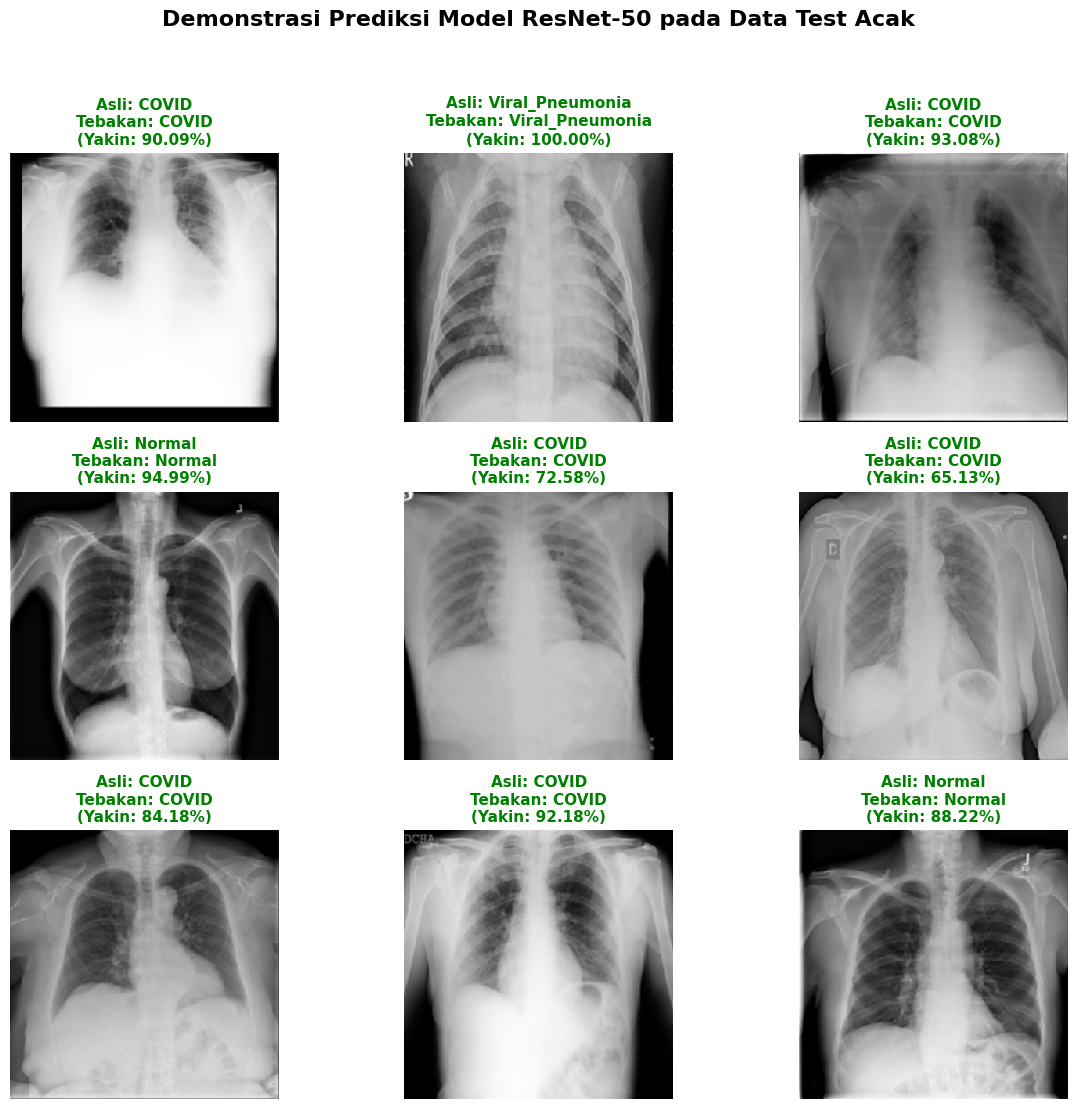

In [3]:
# 3. Mengambil 9 Gambar Secara Acak
random.seed(42) # Boleh dihapus jika ingin hasil acaknya berbeda-beda setiap kali di-run
random.shuffle(test_images_data)
sample_images = test_images_data[:9]

# 4. Melakukan Prediksi dan Menggambar Plot
plt.figure(figsize=(12, 12))
plt.suptitle('Demonstrasi Prediksi Model ResNet-50 pada Data Test Acak', fontsize=16, fontweight='bold', y=0.95)

for i, (img_path, true_label) in enumerate(sample_images):
    # A. Pra-pemrosesan Gambar
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0 # Rescale 0-1
    img_batch = np.expand_dims(img_array, axis=0)
    
    # B. AI Melakukan Prediksi
    prediction = model.predict(img_batch, verbose=0)
    predicted_class_idx = np.argmax(prediction)
    predicted_label = class_names[predicted_class_idx]
    confidence = np.max(prediction) * 100
    
    # C. Menyiapkan Plot
    plt.subplot(3, 3, i+1)
    plt.imshow(img) 
    plt.axis('off')
    
    # D. Menentukan Warna Teks (Hijau = Benar, Merah = Salah)
    teks_warna = 'green' if true_label == predicted_label else 'red'
    
    # E. Membuat Label Teks
    info_teks = f"Asli: {true_label}\nTebakan: {predicted_label}\n(Yakin: {confidence:.2f}%)"
    plt.title(info_teks, color=teks_warna, fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

plt.savefig('../results/random_predictions_showcase.png', dpi=300)
print("\nVisualisasi berhasil disimpan ke folder 'results/random_predictions_showcase.png'")
plt.show()